In [6]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

### `Question-1:`

The dataset is based on NFTs. This is quite large. So, when you will read the dataset, you have to wait. The link of the dataset: https://tinyurl.com/2pfhncqw

Your task is to make a pivote table by using the columns "verification_status", "contract_type", "rarity_score" and "last_sale_price" to find out the total values.

In [7]:
# code here
nfts_df = pd.read_csv( "nfts_train - nfts_train.csv" )
nfts_df.head()

,Unnamed: 0,rarity_score,last_sale_date,last_sale_price,total_supply,creation_date,verification_status,n_of_traits,contract_type,seller_fees,platform_fees,openrarity_enabled,has_website,has_own_twitter,has_discord,has_medium,n_tweets_in_range,avg_likes,avg_replies,avg_retweets,min_likes,min_replies,min_retweets,max_likes,max_replies,max_retweets
0,0,2.000000,2022-11,1.266732,1,2022-04,verified,2,own,1000.0,250,False,False,True,True,False,31,187.967742,8.290323,60.935484,0,0,2,591,28,380
1,1,97.077216,2021-08,1.200357,8888,2021-07,verified,5,own,500.0,250,False,False,True,True,False,11,133.181818,13.454545,55.181818,0,0,7,402,47,239
2,2,139.453086,2022-08,3.180572,8888,2021-07,verified,5,own,500.0,250,False,False,True,True,False,11,133.181818,13.454545,55.181818,0,0,7,402,47,239
3,3,127.753445,2021-08,3.502910,8888,2021-07,verified,5,own,500.0,250,False,False,True,True,False,11,133.181818,13.454545,55.181818,0,0,7,402,47,239
4,4,112.315719,2022-09,4.009567,8888,2021-07,verified,5,own,500.0,250,False,False,True,True,False,11,133.181818,13.454545,55.181818,0,0,7,402,47,239


In [8]:
nfts_df.pivot_table(
    index='verification_status',
    columns='contract_type',
    values=[ 'rarity_score','last_sale_date'],
    aggfunc='sum'
)

last_sale_date  \
contract_type                                                  default   
verification_status                                                      
approved             2021-072022-042022-012022-042022-042022-042022...   
verified             2022-052022-052022-052022-052022-012022-012022...   

                                                                        \
contract_type                                                      own   
verification_status                                                      
approved             2021-122022-102022-052022-022022-012022-022022...   
verified             2022-112021-082022-082021-082022-092021-082021...   

                     rarity_score                
contract_type             default           own  
verification_status                              
approved             3.973082e+08  3.929607e+06  
verified             2.475007e+06  4.165654e+07

In [9]:
nfts_df.pivot_table(
    index=[ 'last_sale_date','verification_status'],
    columns='contract_type',
    values='rarity_score'
    
    
)

contract_type                            default         own
last_sale_date verification_status                          
2021-03        verified               151.434625   94.734300
2021-04        verified              1275.603491   69.259605
2021-05        verified               143.871808  170.176728
2021-06        verified                79.515246  172.719026
2021-07        approved               131.552301         NaN
               verified               238.216065  170.743710
2021-08        verified                98.511117  224.469467
2021-09        approved               656.032687         NaN
               verified                61.560075  229.561749
2021-10        approved               240.501136         NaN
               verified               128.329019  258.342051
2021-11        approved               243.326579         NaN
               verified               158.290881  465.664885
2021-12        approved               515.244038  325.668582
               verified               106.397176  308.978915
2022-01        approved               417.731467  402.234513
               verified               119.454951  362.360922
2022-02        approved             13763.372504  328.732475
               verified               125.488879  316.635495
2022-03        approved              9646.858701  452.635996
               verified               134.363166  246.127222
2022-04        approved              7816.138744  420.216024
               verified               125.440399  176.654965
2022-05        approved             11057.344340  335.679510
               verified               147.288091  253.840610
2022-06        approved               420.353577  339.279293
               verified               156.215190  221.444202
2022-07        approved               678.791392  333.073222
               verified               149.561888  272.606053
2022-08        approved              4702.540477  483.096395
               verified               140.873231  286.215947
2022-09        approved              2393.720023  333.783982
               verified               366.507562  302.361194
2022-10        approved              1833.155469  388.645627
               verified               111.972706  254.716081
2022-11        approved              1570.219616  332.703116
               verified               142.256845  223.184281

### `Question-2:`

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are
- make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
- At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.

There are some challenges to solve this task:
- There is no column that is represented to the brand name of the car. You have to find out on your own.
- Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

In [10]:
cars_df = pd.read_csv("carvana - carvana.csv")
cars_df

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990
...,...,...,...,...
21995,Honda Accord,2014,98085,17590
21996,Dodge Charger,2016,62616,23990
21997,Ford Taurus,2013,50345,16990
21998,Toyota Corolla Hatchback,2020,27945,23990


In [11]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    22000 non-null  object
 1   Year    22000 non-null  int64 
 2   Miles   22000 non-null  int64 
 3   Price   22000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 687.6+ KB


In [12]:
# name of car is actually the brand name 
cars_df['Name']

0                  Chevrolet Trax
1                     GMC Terrain
2                   Jeep Wrangler
3                   Jeep Renegade
4                           BMW X
                   ...           
21995                Honda Accord
21996               Dodge Charger
21997                 Ford Taurus
21998    Toyota Corolla Hatchback
21999                 Honda Civic
Name: Name, Length: 22000, dtype: object

In [13]:

cars_df['Year'].unique()

array([    2018,     2020,     2012,     2019,    20173,     2016,
           2017,     2015,     2014,     2010,    20194,    20165,
           2013,    20133,     2011,  2013500,  2017124,     2021,
           2022,   201650,    20163,    20215,    20113,    20152,
       20141500,   202130,    20204,    20153,  2014500,  2016500,
          20103,    20156,  2017500,   201040,  2013300,  2015200,
        2013150,    20125,    20185,    20166,    20146,    20213,
         202180,   201860,    20184,    20203,    20143,    20144,
         201550,   202050,   202150,    20199,    20219,    20205,
         201730,   202060,  2018500,  2015500,  2010370,   201750,
          20174,   201360,   200970,    20193,    20145,    20164,
          20123,    20176,  2016200,   201560,  2015900,    20161,
        2016900,    20154,    20182,    20157,  2019500,    20183,
          20122,    20129,    20114,  2020150, 20211500,    20135,
          20196,  2014200, 20201500,    20195,    20134,    20

In [14]:
# ya data ko clean karna padega
# year ma first 4 characters ko lo bas baki sab reject

In [15]:
# loop chalo and first 4 digit ko fetch  karo har ek year ki baki ko reject karo

In [16]:
cars_df['Year'] = cars_df['Year'].astype(str).apply(lambda x: x[:4])

In [17]:
cars_df

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,2017,68992,22990
...,...,...,...,...
21995,Honda Accord,2014,98085,17590
21996,Dodge Charger,2016,62616,23990
21997,Ford Taurus,2013,50345,16990
21998,Toyota Corolla Hatchback,2020,27945,23990


In [18]:
cars_df['Year'].unique()

array(['2018', '2020', '2012', '2019', '2017', '2016', '2015', '2014',
       '2010', '2013', '2011', '2021', '2022', '2009', '2023'],
      dtype=object)

In [19]:
# make pivot table
cars_df.pivot_table(
    index='Name',
    columns='Year',
    aggfunc={'Price':'mean','Miles':'median'}
)

Miles                                      \
Year                                2009     2010     2011     2012     2013   
Name                                                                           
Acura ILX                            NaN      NaN      NaN      NaN  88914.0   
Acura MDX                            NaN  98825.0      NaN  62768.0      NaN   
Acura MDX Sport Hybrid               NaN      NaN      NaN      NaN      NaN   
Acura RDX                            NaN      NaN  97867.0  48897.0  80576.0   
Acura RLX                            NaN      NaN      NaN      NaN      NaN   
...                                  ...      ...      ...      ...      ...   
Volvo V                              NaN      NaN      NaN      NaN      NaN   
Volvo XC                             NaN      NaN      NaN  70983.0  41216.0   
smart fortwo                         NaN      NaN      NaN  27966.0  28703.0   
smart fortwo electric drive          NaN      NaN      NaN      NaN      NaN   
smart fortwo electric drive cabrio   NaN      NaN      NaN      NaN      NaN   

                                                                        \
Year                                   2014     2015     2016     2017   
Name                                                                     
Acura ILX                           76067.0      NaN  50733.0  53340.5   
Acura MDX                           92011.0  83298.0  82829.5  43791.0   
Acura MDX Sport Hybrid                  NaN      NaN      NaN      NaN   
Acura RDX                           87856.0  62433.0  57525.0  61143.0   
Acura RLX                           69882.0      NaN      NaN      NaN   
...                                     ...      ...      ...      ...   
Volvo V                                 NaN  67942.0  77319.0      NaN   
Volvo XC                            90078.0  73503.5  76102.0  68674.0   
smart fortwo                        47157.0  48621.0  23996.0      NaN   
smart fortwo electric drive         15626.0  33727.0      NaN      NaN   
smart fortwo electric drive cabrio      NaN      NaN      NaN      NaN   

                                                                             \
Year                                   2018     2019     2020     2021 2022   
Name                                                                          
Acura ILX                           32516.0      NaN      NaN      NaN  NaN   
Acura MDX                           86981.0  50959.0      NaN      NaN  NaN   
Acura MDX Sport Hybrid                  NaN  32675.0      NaN      NaN  NaN   
Acura RDX                               NaN  26612.0  30894.0  10922.0  NaN   
Acura RLX                               NaN      NaN      NaN      NaN  NaN   
...                                     ...      ...      ...      ...  ...   
Volvo V                                 NaN      NaN      NaN      NaN  NaN   
Volvo XC                            41490.0  23902.0      NaN  36590.0  NaN   
smart fortwo                            NaN      NaN      NaN      NaN  NaN   
smart fortwo electric drive         20157.5      NaN      NaN      NaN  NaN   
smart fortwo electric drive cabrio  14825.0      NaN      NaN      NaN  NaN   

                                        Price                                 \
Year                               2023  2009     2010     2011         2012   
Name                                                                           
Acura ILX                           NaN   NaN      NaN      NaN          NaN   
Acura MDX                           NaN   NaN  16590.0      NaN  20790.00000   
Acura MDX Sport Hybrid              NaN   NaN      NaN      NaN          NaN   
Acura RDX                           NaN   NaN      NaN  14990.0  19971.56682   
Acura RLX                           NaN   NaN      NaN      NaN          NaN   
...                                 ...   ...      ...      ...          ...   
Volvo V                             NaN   NaN     

<Axes: ylabel='Density'>

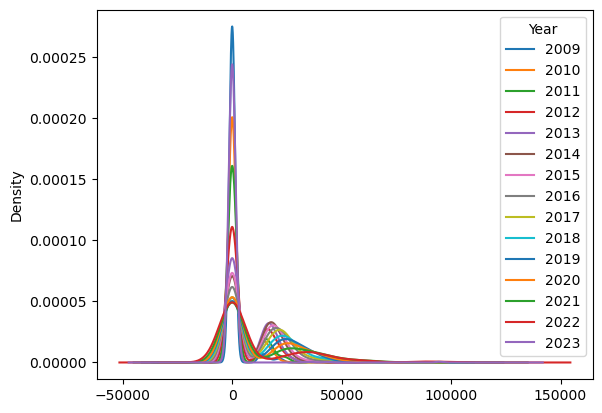

In [20]:
cars_df.pivot_table(
    index='Name',
    columns='Year',
    values='Price',
    aggfunc= 'mean',
    fill_value=0
).plot(kind='kde')

<Axes: ylabel='Density'>

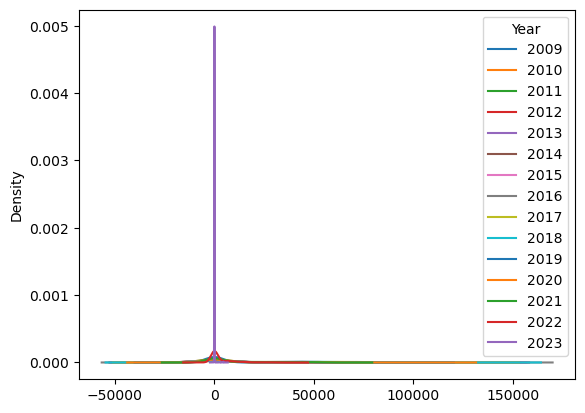

In [21]:
cars_df.pivot_table(
    index='Name',
    columns='Year',
    values='Miles',
    aggfunc= 'median',
    fill_value=0
).plot(kind='kde')

### `Question-3:`

You are given a dataset of **Daily Power Generation in India** of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task
- In this dataset, there are many columns. Two of them are `Actual(MU)` and `Excess(+) / Shortfall (-)`. `Actual(MU)` represents the actual power generation. `Excess(+) / Shortfall (-)` tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
- Find out the month of the day and store it as a new column.
- Find out top 10 frequently appeared power stations in this dataframe.
- Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
- It is hard to get inside if you look through the only pivot table. So plot the pivot table.

In [22]:
import pandas as pd 

In [23]:
power_df = pd.read_csv("PowerGeneration - PowerGeneration.csv")
power_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345268,2022-04-13,Tripura,137.0,32.00,0.00,0.0,32,0,1,0.29,0.0
345269,2022-04-13,NEEPCO.,2027.0,963.50,313.50,650.0,0,0,12,-1.59,0.0
345270,2022-04-13,NHPC,105.0,35.00,0.00,35.0,0,0,0,-0.72,0.0
345271,2022-04-13,NTPC Ltd.,750.0,250.00,0.00,250.0,0,0,11,4.45,0.0


In [30]:
pd.to_datetime(power_df['Dates']).dt.month_name()

0         September
1         September
2         September
3         September
4         September
            ...    
345268        April
345269        April
345270        April
345271        April
345272        April
Name: Dates, Length: 345273, dtype: object

In [ ]:
# quest 1 second line part 
power_df['month'] = pd.to_datetime(power_df['Dates']).dt.month_name()

In [24]:
# creata a new coloumn that if it postive assign  excess and negative shortfall
# if it is greatar than 0 assign postive and if it less than assign it negative 
#                                Excess(+)                            Shortfall (-)


power_df['status'] = power_df['Excess(+) / Shortfall (-)'].apply(lambda x : 'Excess(+)' if x > 0 else 'Shortfall (-)')

In [32]:
# question 1 is completed 
# add a new coloumn of excess and shortfalll
power_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,status,month
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0,Excess(+),September
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0,Shortfall (-),September
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0,Excess(+),September
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0,Excess(+),September
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0,Shortfall (-),September
...,...,...,...,...,...,...,...,...,...,...,...,...,...
345268,2022-04-13,Tripura,137.0,32.00,0.00,0.0,32,0,1,0.29,0.0,Excess(+),April
345269,2022-04-13,NEEPCO.,2027.0,963.50,313.50,650.0,0,0,12,-1.59,0.0,Shortfall (-),April
345270,2022-04-13,NHPC,105.0,35.00,0.00,35.0,0,0,0,-0.72,0.0,Shortfall (-),April
345271,2022-04-13,NTPC Ltd.,750.0,250.00,0.00,250.0,0,0,11,4.45,0.0,Excess(+),April


In [36]:
# Question 2 find most 10 frequenct count power station 
top10 = power_df['Power Station'].value_counts().head(10).index.to_list()
top10

['NTPC Ltd.',
 'NHPC',
 'NPCIL',
 'GMR ENERG',
 'JSWEL',
 'TATA PCL',
 'IBPIL',
 'APL',
 'JPPVL',
 'NLC']

In [40]:
top10_df = power_df[power_df['Power Station'].isin(top10)]
top10_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation,status,month
11,2017-09-01,APL,1320.0,660.0,0.0,660.0,0,22,12,-10.62,0.0,Shortfall (-),September
22,2017-09-01,JPPVL,400.0,0.0,0.0,0.0,0,6,10,3.62,0.0,Excess(+),September
28,2017-09-01,NHPC,4154.2,217.0,0.0,206.0,0,69,75,6.01,0.0,Excess(+),September
29,2017-09-01,NLC,250.0,125.0,0.0,125.0,0,4,2,-1.73,0.0,Shortfall (-),September
30,2017-09-01,NPCIL,1520.0,0.0,0.0,0.0,0,30,35,5.21,0.0,Excess(+),September
...,...,...,...,...,...,...,...,...,...,...,...,...,...
345257,2022-04-13,NHPC,862.0,146.0,0.0,0.0,146,0,11,2.76,0.0,Excess(+),April
345260,2022-04-13,NTPC Ltd.,11730.0,1105.0,500.0,500.0,105,0,246,12.26,0.0,Excess(+),April
345263,2022-04-13,TATA PCL,240.0,0.0,0.0,0.0,0,0,5,0.37,0.0,Excess(+),April
345270,2022-04-13,NHPC,105.0,35.0,0.0,35.0,0,0,0,-0.72,0.0,Shortfall (-),April


In [42]:
# Question 3 pivot table of top_10 power station 
top10_df.pivot_table(
    index='month',
    columns='Power Station' ,
    values='Actual(MU)' ,
    aggfunc='sum'

)

Power Station,APL,GMR ENERG,IBPIL,JPPVL,JSWEL,NHPC,NLC,NPCIL,NTPC Ltd.,TATA PCL
month,,,,,,,,,,
April,17446,3724,0,4254,3106,7883,7177,12989,101832,2657
August,19558,3859,0,5246,3531,16431,7571,16752,115426,2674
December,24951,4910,0,4876,3701,4897,8971,21072,130939,3025
February,18784,3830,0,3533,3052,4233,8549,15393,111891,2533
January,21617,4269,0,4006,3709,3981,8682,17214,119130,2511
July,19657,4056,0,5122,3453,16679,7956,18128,116488,2618
June,18858,4259,0,6088,3523,14809,8600,18299,114132,2959
March,30425,6200,0,5926,5218,9899,12706,25745,176659,4189
May,15636,3891,0,4673,3420,10414,7074,13954,96795,2698


<Axes: xlabel='month'>

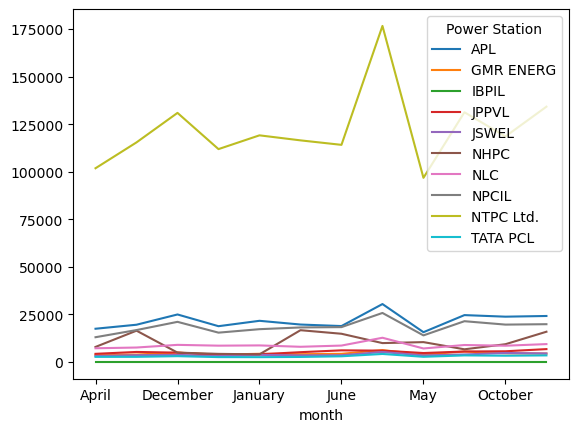

In [43]:
top10_df.pivot_table(
    index='month',
    columns='Power Station' ,
    values='Actual(MU)' ,
    aggfunc='sum'

).plot(kind='line')

In [ ]:
# har ek power station ka actual mu 

###`Q-4` You are given a file `question-answer.csv`. Your task is to make a dataframe from it with two columns - `question` and `answers`.

* Questions in the file start from `Q<number>`; E.g.  `Q1` denotes question no. `1`
* Answers starts from `Ans<number>`; Eg. `Ans1` denotes answer of question no `1`
* MAke sure you look at columns name carefully

CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [45]:
import pandas as pd

download_url = 'https://drive.google.com/uc?export=download&id=10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY'
ques_df = pd.read_csv(download_url)


In [46]:
ques_df

,Unnamed: 0,2
0,0,Q1-What is Data Science?
1,1,"Ans1-Data Science combines statistics, maths, ..."
2,2,Q2-2. How is logistic regression done?
3,3,Ans2-Logistic regression measures the relation...
4,4,Q3-How do you build a random forest model?
5,5,Ans3-A random forest is built up of a number o...
6,6,Q4-How can you avoid overfitting your model?
7,7,Ans4-Overfitting refers to a model that is onl...
8,8,Q5-You are given a data set consisting of vari...
9,9,Ans5-The following are ways to handle missing ...


In [ ]:
# task is to make a dataframe with question and answer . 
# is even is question and odd is answer 
# use slicing to fetch all question and answer 
ques_df.iloc[0:: 2]  # start with 0 get all questions
ques_df.iloc[1:: 2]  # start with 1 get all answers 

,Unnamed: 0,2
1,1,"Ans1-Data Science combines statistics, maths, ..."
3,3,Ans2-Logistic regression measures the relation...
5,5,Ans3-A random forest is built up of a number o...
7,7,Ans4-Overfitting refers to a model that is onl...
9,9,Ans5-The following are ways to handle missing ...
11,11,Ans6-Bag of Words is a representation of text ...
13,13,Ans7-Machine learning classification algorithm...
15,15,Ans8-A time series is a set of observations or...
17,17,Ans9-The principle behind causal forecasting i...
19,19,Ans10-(INNER) JOIN: Returns records that have ...


In [ ]:
# add the  ques columns 
ques_df['Questions'] = ques_df.iloc[0::2]['2']

In [ ]:
# add the  ans columns 
ques_df['Answers '] = ques_df.iloc[1::2]['2']


In [53]:
question_df= ques_df.iloc[0::2]['2'].reset_index()
question_df

,index,2
0,0,Q1-What is Data Science?
1,2,Q2-2. How is logistic regression done?
2,4,Q3-How do you build a random forest model?
3,6,Q4-How can you avoid overfitting your model?
4,8,Q5-You are given a data set consisting of vari...
5,10,Q6-What is bag of words? How we can use it for...
6,12,Q7-How can we use machine learning for text cl...
7,14,Q8-What is a time series?
8,16,Q9-How is time series different from the usual...
9,18,Q10-What are the different types of joins? Wha...


In [54]:
answer_df  = ques_df.iloc[1::2]['2'].reset_index()
answer_df

,index,2
0,1,"Ans1-Data Science combines statistics, maths, ..."
1,3,Ans2-Logistic regression measures the relation...
2,5,Ans3-A random forest is built up of a number o...
3,7,Ans4-Overfitting refers to a model that is onl...
4,9,Ans5-The following are ways to handle missing ...
5,11,Ans6-Bag of Words is a representation of text ...
6,13,Ans7-Machine learning classification algorithm...
7,15,Ans8-A time series is a set of observations or...
8,17,Ans9-The principle behind causal forecasting i...
9,19,Ans10-(INNER) JOIN: Returns records that have ...


,2,2
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


In [ ]:
ques_df

,Unnamed: 0,2,Questions,Answers
0,0,Q1-What is Data Science?,Q1-What is Data Science?,NaN
1,1,"Ans1-Data Science combines statistics, maths, ...",NaN,"Ans1-Data Science combines statistics, maths, ..."
2,2,Q2-2. How is logistic regression done?,Q2-2. How is logistic regression done?,NaN
3,3,Ans2-Logistic regression measures the relation...,NaN,Ans2-Logistic regression measures the relation...
4,4,Q3-How do you build a random forest model?,Q3-How do you build a random forest model?,NaN
5,5,Ans3-A random forest is built up of a number o...,NaN,Ans3-A random forest is built up of a number o...
6,6,Q4-How can you avoid overfitting your model?,Q4-How can you avoid overfitting your model?,NaN
7,7,Ans4-Overfitting refers to a model that is onl...,NaN,Ans4-Overfitting refers to a model that is onl...
8,8,Q5-You are given a data set consisting of vari...,Q5-You are given a data set consisting of vari...,NaN
9,9,Ans5-The following are ways to handle missing ...,NaN,Ans5-The following are ways to handle missing ...


In [ ]:
ques_df[['Questions',"Answers "]].melt().dropna().groupby('variable').groups

{'Answers ': [21, 23, 25, 27, 29, 31, 33, 35, 37, 39], 'Questions': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]}

In [ ]:
ques_df.melt(id_vars='Questions',value_vars='Answers ')

,Questions,variable,value
0,Q1-What is Data Science?,Answers,NaN
1,NaN,Answers,"Ans1-Data Science combines statistics, maths, ..."
2,Q2-2. How is logistic regression done?,Answers,NaN
3,NaN,Answers,Ans2-Logistic regression measures the relation...
4,Q3-How do you build a random forest model?,Answers,NaN
5,NaN,Answers,Ans3-A random forest is built up of a number o...
6,Q4-How can you avoid overfitting your model?,Answers,NaN
7,NaN,Answers,Ans4-Overfitting refers to a model that is onl...
8,Q5-You are given a data set consisting of vari...,Answers,NaN
9,NaN,Answers,Ans5-The following are ways to handle missing ...


###`Q-5`: Print Question and answer of those questions which does not contains any question mark (`?`).


In [60]:
pd.concat([question_df,answer_df],axis=1).drop(columns='index')

,2,2
0,Q1-What is Data Science?,"Ans1-Data Science combines statistics, maths, ..."
1,Q2-2. How is logistic regression done?,Ans2-Logistic regression measures the relation...
2,Q3-How do you build a random forest model?,Ans3-A random forest is built up of a number o...
3,Q4-How can you avoid overfitting your model?,Ans4-Overfitting refers to a model that is onl...
4,Q5-You are given a data set consisting of vari...,Ans5-The following are ways to handle missing ...
5,Q6-What is bag of words? How we can use it for...,Ans6-Bag of Words is a representation of text ...
6,Q7-How can we use machine learning for text cl...,Ans7-Machine learning classification algorithm...
7,Q8-What is a time series?,Ans8-A time series is a set of observations or...
8,Q9-How is time series different from the usual...,Ans9-The principle behind causal forecasting i...
9,Q10-What are the different types of joins? Wha...,Ans10-(INNER) JOIN: Returns records that have ...


###`Q 6-10` LOG and EMPLOYEE
6. Show `activity` details month wise. Show count for each `activity`
7. Find employee who did most `activity` in January month.
8. Employee who have worked most no of times on Weekends.
9. Which activity is logged most on buisness days.
10. Week Days wise activity table.
```
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

```

Note(for common field):- Employee file has `EMPLOYEE_ID` and LOG file has `emp_id`

In [61]:
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
log_file

,Log_ID,dt,dept,emp_id,activity,eqpt
0,1000,2022-01-07,Dept6,115,Cleaning,UPS
1,1001,2022-01-08,Dept4,105,Cleaning,Generator
2,1002,2022-01-09,Dept3,112,Inspection,CPU
3,1003,2022-01-10,Dept4,120,Inspection,UPS
4,1004,2022-01-11,Dept3,138,Checking,Battery
...,...,...,...,...,...,...
360,1360,2023-01-02,Dept2,122,Repair,AC
361,1361,2023-01-03,Dept4,116,Checking,Server
362,1362,2023-01-04,Dept4,110,Checking,CPU
363,1363,2023-01-05,Dept4,102,Inspection,AC


In [62]:
# month wise actiavity ka liyaa first coloumn banho 
log_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Log_ID    365 non-null    int64 
 1   dt        365 non-null    object
 2   dept      365 non-null    object
 3   emp_id    365 non-null    int64 
 4   activity  365 non-null    object
 5   eqpt      365 non-null    object
dtypes: int64(2), object(4)
memory usage: 17.2+ KB


In [63]:
# make a coloumn of month is log file 
# use the function to convert into data time  then use month_name func to extract it. 
pd.to_datetime(log_file['dt']).dt.month_name()

0      January
1      January
2      January
3      January
4      January
        ...   
360    January
361    January
362    January
363    January
364    January
Name: dt, Length: 365, dtype: object

In [64]:
log_file['month']= pd.to_datetime(log_file['dt']).dt.month_name()

In [65]:
log_file.pivot_table(
    index='month',
    columns='activity',
    values= 'Log_ID',
    aggfunc='count'
)

activity,Checking,Cleaning,Inspection,Repair
month,,,,
April,5,11,9,5
August,8,10,9,4
December,6,7,12,6
February,7,7,4,10
January,7,10,9,5
July,6,6,14,5
June,5,7,8,10
March,8,6,5,12
May,5,8,7,11


In [ ]:
## every month activities 

In [67]:
employes= pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")
employes

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST
5,105,David,Austin,DAUSTIN
6,106,Valli,Pataballa,VPATABAL
7,107,Diana,Lorentz,DLORENTZ
8,108,Nancy,Greenberg,NGREENBE
9,109,Daniel,Faviet,DFAVIET


In [68]:
# fix the employeee name 
employes['FIRST_NAME'] + " "  + employes['LAST_NAME']

0           Steven King
1         Neena Kochhar
2           Lex De Haan
3      Alexander Hunold
4           Bruce Ernst
5          David Austin
6       Valli Pataballa
7         Diana Lorentz
8       Nancy Greenberg
9         Daniel Faviet
10            John Chen
11       Ismael Sciarra
12                  NaN
13            Luis Popp
14         Den Raphaely
15       Alexander Khoo
16         Shelli Baida
17         Sigal Tobias
18           Guy Himuro
19     Karen Colmenares
20        Matthew Weiss
21                  NaN
22       Payam Kaufling
23       Shanta Vollman
24        Kevin Mourgos
25          Julia Nayer
26    Irene Mikkilineni
27         James Landry
28        Steven Markle
29         Laura Bissot
30       Mozhe Atkinson
31         James Marlow
32                  NaN
33         Jason Mallin
34       Michael Rogers
35               Ki Gee
36     Hazel Philtanker
37        Renske Ladwig
38       Stephen Stiles
39             John Seo
40         Joshua Patel
dtype: object

In [ ]:
# add the employes name 
employes['name'] = employes['FIRST_NAME'] + " "  + employes['LAST_NAME']

In [ ]:
employes

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,name
0,100,Steven,King,SKING,Steven King
1,101,Neena,Kochhar,NKOCHHAR,Neena Kochhar
2,102,Lex,De Haan,LDEHAAN,Lex De Haan
3,103,Alexander,Hunold,AHUNOLD,Alexander Hunold
4,104,Bruce,Ernst,BERNST,Bruce Ernst
5,105,David,Austin,DAUSTIN,David Austin
6,106,Valli,Pataballa,VPATABAL,Valli Pataballa
7,107,Diana,Lorentz,DLORENTZ,Diana Lorentz
8,108,Nancy,Greenberg,NGREENBE,Nancy Greenberg
9,109,Daniel,Faviet,DFAVIET,Daniel Faviet


In [ ]:
# use the merging concept to merge it 
final_df = employes.merge(log_file,left_on='EMPLOYEE_ID',right_on='emp_id')
final_df

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,name,Log_ID,dt,dept,emp_id,activity,eqpt,month
0,100,Steven,King,SKING,Steven King,1116,2022-05-03,Dept2,100,Checking,CPU,May
1,100,Steven,King,SKING,Steven King,1139,2022-05-26,Dept2,100,Cleaning,UPS,May
2,100,Steven,King,SKING,Steven King,1181,2022-07-07,Dept6,100,Cleaning,CPU,July
3,100,Steven,King,SKING,Steven King,1191,2022-07-17,Dept4,100,Cleaning,Server,July
4,100,Steven,King,SKING,Steven King,1269,2022-10-03,Dept6,100,Repair,UPS,October
...,...,...,...,...,...,...,...,...,...,...,...,...
290,140,Joshua,Patel,JPATEL,Joshua Patel,1234,2022-08-29,Dept4,140,Repair,Fan,August
291,140,Joshua,Patel,JPATEL,Joshua Patel,1253,2022-09-17,Dept4,140,Checking,AC,September
292,140,Joshua,Patel,JPATEL,Joshua Patel,1281,2022-10-15,Dept4,140,Inspection,CPU,October
293,140,Joshua,Patel,JPATEL,Joshua Patel,1329,2022-12-02,Dept2,140,Cleaning,CPU,December


In [ ]:
final_df

In [ ]:
# month is january and find the employ name and its activity . 
final_df[final_df['month'] == 'January'][['name','activity']].value_counts()

name              activity  
Matthew Weiss     Inspection    2
Alexander Khoo    Cleaning      1
Lex De Haan       Checking      1
Stephen Stiles    Checking      1
Shelli Baida      Repair        1
                  Checking      1
Payam Kaufling    Repair        1
                  Inspection    1
                  Cleaning      1
Nancy Greenberg   Checking      1
Lex De Haan       Inspection    1
Ki Gee            Inspection    1
Daniel Faviet     Cleaning      1
Ki Gee            Cleaning      1
Kevin Mourgos     Repair        1
Karen Colmenares  Cleaning      1
John Chen         Checking      1
Jason Mallin      Repair        1
James Marlow      Repair        1
James Landry      Checking      1
Diana Lorentz     Cleaning      1
David Austin      Cleaning      1
Steven Markle     Cleaning      1
Name: count, dtype: int64

In [ ]:
# do groub by month then fetch januarny month use the fency indexing and get the two columns 
# you need name and activity . 
final_df.groupby('month').get_group('January')[['name','activity']]

,name,activity
15,Lex De Haan,Checking
24,Lex De Haan,Inspection
39,David Austin,Cleaning
52,Diana Lorentz,Cleaning
56,Nancy Greenberg,Checking
66,Daniel Faviet,Cleaning
84,John Chen,Checking
92,NaN,Inspection
93,NaN,Cleaning
108,Alexander Khoo,Cleaning


In [ ]:
final_df['na']

In [ ]:
month_df = final_df.pivot_table(
    index='name',
    columns='month',
    values='activity',
    aggfunc= 'count',
    
)
month_df['January'].sort_values(ascending=False)
# payam kaufling employe na janunary ma sabsa jada kam kiya 

name
Payam Kaufling       3.0
Shelli Baida         2.0
Matthew Weiss        2.0
Lex De Haan          2.0
Ki Gee               2.0
Alexander Khoo       1.0
Daniel Faviet        1.0
Stephen Stiles       1.0
Nancy Greenberg      1.0
Kevin Mourgos        1.0
Karen Colmenares     1.0
John Chen            1.0
Jason Mallin         1.0
James Marlow         1.0
James Landry         1.0
Diana Lorentz        1.0
David Austin         1.0
Steven Markle        1.0
Alexander Hunold     NaN
Bruce Ernst          NaN
Den Raphaely         NaN
Guy Himuro           NaN
Hazel Philtanker     NaN
Irene Mikkilineni    NaN
Ismael Sciarra       NaN
John Seo             NaN
Joshua Patel         NaN
Julia Nayer          NaN
Laura Bissot         NaN
Luis Popp            NaN
Michael Rogers       NaN
Mozhe Atkinson       NaN
Neena Kochhar        NaN
Renske Ladwig        NaN
Shanta Vollman       NaN
Sigal Tobias         NaN
Steven King          NaN
Valli Pataballa      NaN
Name: January, dtype: float64

In [ ]:
month_df['January'].sort_values(ascending=False).head(1)

name
Payam Kaufling    3.0
Name: January, dtype: float64

In [ ]:
# employee who work most number of times on weekends
# slicing sa weekend nikalo 
final_df['day'] = pd.to_datetime(final_df['dt']).dt.day_name()


In [ ]:
# name is catoegirical and days is cateorgical activity is 
week_df = final_df.pivot_table(
    index='name',
    columns= 'day',
    values= 'activity',
    aggfunc= 'count',
)
week_df['Sunday'].sort_values(ascending=False)
# ya raho wo employers jinhno sunday ko sabsa jada kam kiya ha 

name
Daniel Faviet        4.0
Stephen Stiles       4.0
Matthew Weiss        4.0
Den Raphaely         3.0
Jason Mallin         3.0
Alexander Hunold     2.0
Lex De Haan          2.0
David Austin         2.0
James Landry         2.0
James Marlow         2.0
Nancy Greenberg      2.0
Kevin Mourgos        2.0
Laura Bissot         2.0
Payam Kaufling       1.0
Mozhe Atkinson       1.0
Joshua Patel         1.0
Julia Nayer          1.0
Alexander Khoo       1.0
John Seo             1.0
Irene Mikkilineni    1.0
Hazel Philtanker     1.0
Steven King          1.0
Bruce Ernst          NaN
Diana Lorentz        NaN
Guy Himuro           NaN
Ismael Sciarra       NaN
John Chen            NaN
Karen Colmenares     NaN
Ki Gee               NaN
Luis Popp            NaN
Michael Rogers       NaN
Neena Kochhar        NaN
Renske Ladwig        NaN
Shanta Vollman       NaN
Shelli Baida         NaN
Sigal Tobias         NaN
Steven Markle        NaN
Valli Pataballa      NaN
Name: Sunday, dtype: float64

In [ ]:
final_df

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,name,Log_ID,dt,dept,emp_id,activity,eqpt,month,day
0,100,Steven,King,SKING,Steven King,1116,2022-05-03,Dept2,100,Checking,CPU,May,Tuesday
1,100,Steven,King,SKING,Steven King,1139,2022-05-26,Dept2,100,Cleaning,UPS,May,Thursday
2,100,Steven,King,SKING,Steven King,1181,2022-07-07,Dept6,100,Cleaning,CPU,July,Thursday
3,100,Steven,King,SKING,Steven King,1191,2022-07-17,Dept4,100,Cleaning,Server,July,Sunday
4,100,Steven,King,SKING,Steven King,1269,2022-10-03,Dept6,100,Repair,UPS,October,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,140,Joshua,Patel,JPATEL,Joshua Patel,1234,2022-08-29,Dept4,140,Repair,Fan,August,Monday
291,140,Joshua,Patel,JPATEL,Joshua Patel,1253,2022-09-17,Dept4,140,Checking,AC,September,Saturday
292,140,Joshua,Patel,JPATEL,Joshua Patel,1281,2022-10-15,Dept4,140,Inspection,CPU,October,Saturday
293,140,Joshua,Patel,JPATEL,Joshua Patel,1329,2022-12-02,Dept2,140,Cleaning,CPU,December,Friday


In [ ]:
# Which activity is logged most on buisness days.
# index is activity coloumn is business and logged in values 

final_df.pivot_table(
    index='activity',
    columns='day',
    values= 'Log_ID',
    aggfunc= 'count'
)#.sort_values(by = [ 'Friday','Monday'],ascending=False)

day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
activity,,,,,,,
Checking,7,9,9,11,8,12,13
Cleaning,15,9,8,9,14,8,9
Inspection,15,11,6,13,14,13,9
Repair,8,12,11,11,11,11,9


### `Q-11`:

1. There are missing value in first name of employee. Fill it using email and last name field.

> E.g- `email` -> JMURMAN and `last_name` -> 'Urman' -> so make it's first name as 'JM', Sort of (Email- lastname).

> Email is constructed from initials of first name concate with lastname. Your Task is to fill first name initials in missing data.

2. You can see email field don't have any domain name. Change this to full email addreess with domain as 'campusx.com'.
E.g- Email field -> `JMURMAN`  result -> `JMURMAN@CAMPUSX.COM`

3. Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]

In [ ]:
final_df['name'].str.startswith('A')


0      False
1      False
2      False
3      False
4      False
       ...  
290    False
291    False
292    False
293    False
294    False
Name: name, Length: 295, dtype: object

In [ ]:
employes['name'].str.startswith('A')

0     False
1     False
2     False
3      True
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12      NaN
13    False
14    False
15     True
16    False
17    False
18    False
19    False
20    False
21      NaN
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32      NaN
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
Name: name, dtype: object

In [ ]:
test_employes = employes.dropna(subset='name')
test_employes

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,name
0,100,Steven,King,SKING,Steven King
1,101,Neena,Kochhar,NKOCHHAR,Neena Kochhar
2,102,Lex,De Haan,LDEHAAN,Lex De Haan
3,103,Alexander,Hunold,AHUNOLD,Alexander Hunold
4,104,Bruce,Ernst,BERNST,Bruce Ernst
5,105,David,Austin,DAUSTIN,David Austin
6,106,Valli,Pataballa,VPATABAL,Valli Pataballa
7,107,Diana,Lorentz,DLORENTZ,Diana Lorentz
8,108,Nancy,Greenberg,NGREENBE,Nancy Greenberg
9,109,Daniel,Faviet,DFAVIET,Daniel Faviet


In [ ]:
test_employes[test_employes['name'].str.startswith('A')]

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,name
3,103,Alexander,Hunold,AHUNOLD,Alexander Hunold
15,115,Alexander,Khoo,AKHOO,Alexander Khoo


In [69]:
employes

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,100,Steven,King,SKING
1,101,Neena,Kochhar,NKOCHHAR
2,102,Lex,De Haan,LDEHAAN
3,103,Alexander,Hunold,AHUNOLD
4,104,Bruce,Ernst,BERNST
5,105,David,Austin,DAUSTIN
6,106,Valli,Pataballa,VPATABAL
7,107,Diana,Lorentz,DLORENTZ
8,108,Nancy,Greenberg,NGREENBE
9,109,Daniel,Faviet,DFAVIET
